In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import zipfile
import os

# Path to your zip file in Google Drive
zip_path = '/content/drive/MyDrive/my_final_dataset.zip'

# Path where files will be extracted
extract_path = '/content/dataset'

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Zip file successfully extracted!")

Zip file successfully extracted!


In [ ]:
import tensorflow as tf

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

print("Loading Training Images...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/my_final_dataset/train',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

print("\nLoading Validation Images...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/my_final_dataset/validation',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

print("\nLoading Testing Images (Shuffle=False)...")
test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/my_final_dataset/test',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

# Get class names and total number of classes
class_names = train_ds.class_names
num_classes = len(class_names)

print(f"\nClass Names: {class_names}")
print(f"Total {num_classes} classes found.")

Loading Training Images...
Found 9651 files belonging to 6 classes.

Loading Validation Images...
Found 2065 files belonging to 6 classes.

Loading Testing Images (Shuffle=False)...
Found 2070 files belonging to 6 classes.

Class Names: ['calculus', 'caries', 'gingivitis', 'healthy_teeth', 'mouth_ulcer', 'tooth_discoloration']
Total 6 classes found.


In [ ]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
fast_test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset performance optimization complete!")

Dataset performance optimization complete!


In [ ]:
from tensorflow.keras import layers, models
import tensorflow as tf

# 1. Preprocessing layer specifically for MobileNetV3
preprocess_input = tf.keras.applications.mobilenet_v3.preprocess_input

# 2. Load the base MobileNetV3Large model with ImageNet weights
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base layers initially

# 3. Build the model architecture
inputs = tf.keras.Input(shape=(224, 224, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# 4. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("MobileNetV3Large model successfully built and compiled!")

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV3Large model successfully built and compiled!


In [ ]:
# Checkpoint setup to save the best model in your Google Drive
checkpoint_path = "/content/drive/MyDrive/mobilenetv3_checkpoint.keras"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

# Start training for 15 epochs
print("Training started for 15 epochs... Please wait.")
history = model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=[model_checkpoint]
)

Training started for 15 epochs... Please wait.
Epoch 1/15
301/302 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5151 - loss: 1.2856
Epoch 1: val_loss improved from None to 0.49499, saving model to /content/drive/MyDrive/mobilenetv3_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/mobilenetv3_checkpoint.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 81s 132ms/step - accuracy: 0.6670 - loss: 0.8705 - val_accuracy: 0.8136 - val_loss: 0.4950
Epoch 2/15
301/302 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8123 - loss: 0.4976
Epoch 2: val_loss improved from 0.49499 to 0.39175, saving model to /content/drive/MyDrive/mobilenetv3_checkpoint.keras

Epoch 2: finished saving model to /content/drive/MyDrive/mobilenetv3_checkpoint.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8232 - loss: 0.4746 - val_accuracy: 0.8562 - val_loss: 0.3918
Epoch 3/15
301/302 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8524 - loss: 0.3988
Epoch 3: val_loss improved from 0.39175 to 

In [ ]:
# 1. Unfreeze the base model layers
base_model.trainable = True

print(f"Number of layers in the base model: {len(base_model.layers)}")

# Freeze all layers except the last 20 layers
fine_tune_at = len(base_model.layers) - 20

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 2. Re-compile the model with a very low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model re-compiled for Fine-Tuning!")

# 3. Setup checkpoint callback
fine_tune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/mobilenetv3_checkpoint.keras",
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

# 4. Start Fine-Tuning for 7 more epochs (Epochs 16 to 22)
print("Fine-tuning started... Please wait.")
fine_tune_history = model.fit(
    train_ds,
    epochs=15 + 7,               # Epoch 16 to 22
    initial_epoch=15,            # Resumes from epoch 15
    validation_data=val_ds,
    callbacks=[fine_tune_checkpoint]
)

Number of layers in the base model: 187
Model re-compiled for Fine-Tuning!
Fine-tuning started... Please wait.
Epoch 16/22
301/302 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7910 - loss: 0.6127
Epoch 16: val_loss improved from None to 0.29940, saving model to /content/drive/MyDrive/mobilenetv3_checkpoint.keras

Epoch 16: finished saving model to /content/drive/MyDrive/mobilenetv3_checkpoint.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - accuracy: 0.8137 - loss: 0.5401 - val_accuracy: 0.8881 - val_loss: 0.2994
Epoch 17/22
300/302 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8472 - loss: 0.4157
Epoch 17: val_loss improved from 0.29940 to 0.27956, saving model to /content/drive/MyDrive/mobilenetv3_checkpoint.keras

Epoch 17: finished saving model to /content/drive/MyDrive/mobilenetv3_checkpoint.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.8566 - loss: 0.3893 - val_accuracy: 0.8935 - val_loss: 0.2796
Epoch 18/22
301/302 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accu

In [ ]:
import tensorflow as tf

# 1. Load the best saved MobileNetV3 model from Google Drive
print("Loading the best saved MobileNetV3 model...")
best_model = tf.keras.models.load_model('/content/drive/MyDrive/mobilenetv3_checkpoint.keras')

# 2. Evaluate performance on the Test Dataset
print("\nEvaluating model on Test Dataset...")
test_loss, test_accuracy = best_model.evaluate(fast_test_ds)

# 3. Print final metrics
print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

Loading the best saved MobileNetV3 model...

Evaluating model on Test Dataset...
65/65 ━━━━━━━━━━━━━━━━━━━━ 24s 261ms/step - accuracy: 0.8855 - loss: 0.3313

Final Test Loss: 0.3313
Final Test Accuracy: 88.55%


Full training history successfully saved to: /content/drive/MyDrive/mobilenetv3_training_history.json



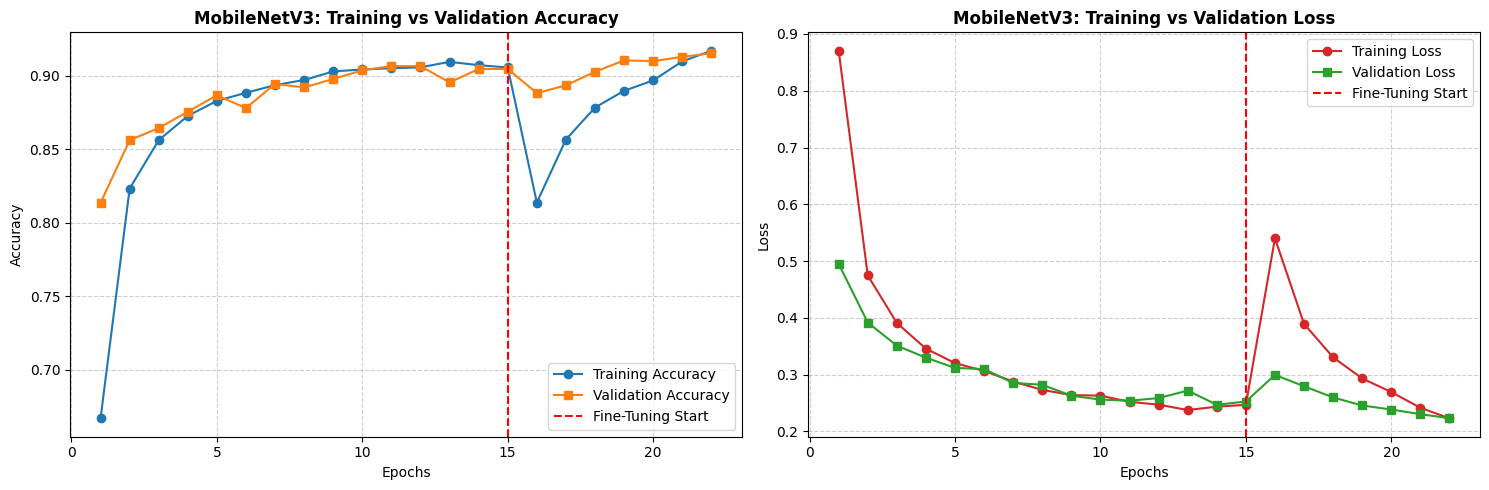

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# 1. Combine initial training and fine-tuning histories
full_history = {
    'accuracy': history.history['accuracy'] + fine_tune_history.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'] + fine_tune_history.history['val_accuracy'],
    'loss': history.history['loss'] + fine_tune_history.history['loss'],
    'val_loss': history.history['val_loss'] + fine_tune_history.history['val_loss']
}

# 2. Save training history as a JSON file in Google Drive
history_file_path = '/content/drive/MyDrive/mobilenetv3_training_history.json'
with open(history_file_path, 'w') as f:
    json.dump(full_history, f)

print(f"Full training history successfully saved to: {history_file_path}\n")

# 3. Plot Training vs Validation Accuracy and Loss
epochs = range(1, len(full_history['accuracy']) + 1)

plt.figure(figsize=(15, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, full_history['accuracy'], label='Training Accuracy', color='#1f77b4', marker='o')
plt.plot(epochs, full_history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', marker='s')
plt.axvline(x=15, color='red', linestyle='--', label='Fine-Tuning Start')
plt.title('MobileNetV3: Training vs Validation Accuracy', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, full_history['loss'], label='Training Loss', color='#d62728', marker='o')
plt.plot(epochs, full_history['val_loss'], label='Validation Loss', color='#2ca02c', marker='s')
plt.axvline(x=15, color='red', linestyle='--', label='Fine-Tuning Start')
plt.title('MobileNetV3: Training vs Validation Loss', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/mobilenetv3_training_plots.png', dpi=300)
plt.show()

Generating predictions on Test Dataset...
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step

             MOBILENETV3 CLASSIFICATION REPORT
                     precision    recall  f1-score   support

           calculus       0.85      0.80      0.82       345
             caries       0.93      0.94      0.94       345
         gingivitis       0.75      0.90      0.82       345
      healthy_teeth       0.93      0.82      0.87       345
        mouth_ulcer       0.98      0.97      0.97       345
tooth_discoloration       0.90      0.89      0.89       345

           accuracy                           0.89      2070
          macro avg       0.89      0.89      0.89      2070
       weighted avg       0.89      0.89      0.89      2070



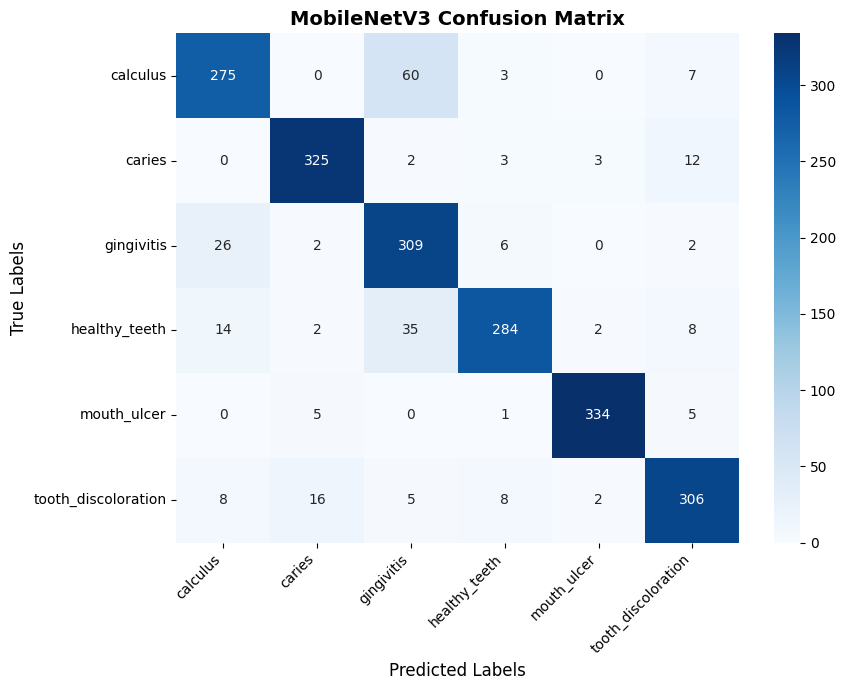

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("Generating predictions on Test Dataset...")
y_true = np.concatenate([y for x, y in fast_test_ds], axis=0)
predictions = best_model.predict(fast_test_ds)
y_pred = np.argmax(predictions, axis=1)

print("\n" + "="*60)
print("             MOBILENETV3 CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*60)

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('MobileNetV3 Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/mobilenetv3_confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
import tensorflow as tf

# 1. Load the best saved model from Google Drive
print("Loading saved model from Google Drive...")
model = tf.keras.models.load_model('/content/drive/MyDrive/mobilenetv3_checkpoint.keras')

# 2. Re-compile the model with a low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Setup the checkpoint callback
checkpoint_path = "/content/drive/MyDrive/mobilenetv3_checkpoint.keras"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

# 4. Continue training from Epoch 22 to 30 (8 additional epochs)
print("Continuing training from Epoch 22 to 30... Please wait.")
extended_history = model.fit(
    train_ds,
    epochs=30,             # Target total epochs (22 + 8 = 30)
    initial_epoch=22,      # Starts from epoch 22
    validation_data=val_ds,
    callbacks=[model_checkpoint]
)

Loading saved model from Google Drive...
Continuing training from Epoch 22 to 30... Please wait.
Epoch 23/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9188 - loss: 0.2208
Epoch 23: val_loss improved from None to 0.21536, saving model to /content/drive/MyDrive/mobilenetv3_checkpoint.keras

Epoch 23: finished saving model to /content/drive/MyDrive/mobilenetv3_checkpoint.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 96s 151ms/step - accuracy: 0.9194 - loss: 0.2182 - val_accuracy: 0.9201 - val_loss: 0.2154
Epoch 24/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9284 - loss: 0.2051
Epoch 24: val_loss improved from 0.21536 to 0.20992, saving model to /content/drive/MyDrive/mobilenetv3_checkpoint.keras

Epoch 24: finished saving model to /content/drive/MyDrive/mobilenetv3_checkpoint.keras
302/302 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9276 - loss: 0.2019 - val_accuracy: 0.9211 - val_loss: 0.2099
Epoch 25/30
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9341 

In [ ]:
import tensorflow as tf

# 1. Load the updated best model from Google Drive
print("Loading the updated best MobileNetV3 model...")
best_model = tf.keras.models.load_model('/content/drive/MyDrive/mobilenetv3_checkpoint.keras')

# 2. Evaluate on the Test Dataset
print("\nEvaluating updated model on Test Dataset...")
test_loss, test_accuracy = best_model.evaluate(fast_test_ds)

print("\n" + "="*40)
print("       UPDATED FINAL TEST RESULTS")
print("="*40)
print(f"Overall Testing Accuracy : {test_accuracy * 100:.2f}%")
print(f"Overall Testing Loss     : {test_loss:.4f}")
print("="*40)

Loading the updated best MobileNetV3 model...

Evaluating updated model on Test Dataset...
65/65 ━━━━━━━━━━━━━━━━━━━━ 24s 267ms/step - accuracy: 0.9097 - loss: 0.2700

       UPDATED FINAL TEST RESULTS
Overall Testing Accuracy : 90.97%
Overall Testing Loss     : 0.2700


Generating updated predictions on Test Dataset...
65/65 ━━━━━━━━━━━━━━━━━━━━ 17s 169ms/step

        UPDATED MOBILENETV3 CLASSIFICATION REPORT
                     precision    recall  f1-score   support

           calculus       0.88      0.84      0.86       345
             caries       0.96      0.95      0.96       345
         gingivitis       0.80      0.91      0.85       345
      healthy_teeth       0.93      0.86      0.89       345
        mouth_ulcer       0.99      0.98      0.98       345
tooth_discoloration       0.92      0.92      0.92       345

           accuracy                           0.91      2070
          macro avg       0.91      0.91      0.91      2070
       weighted avg       0.91      0.91      0.91      2070



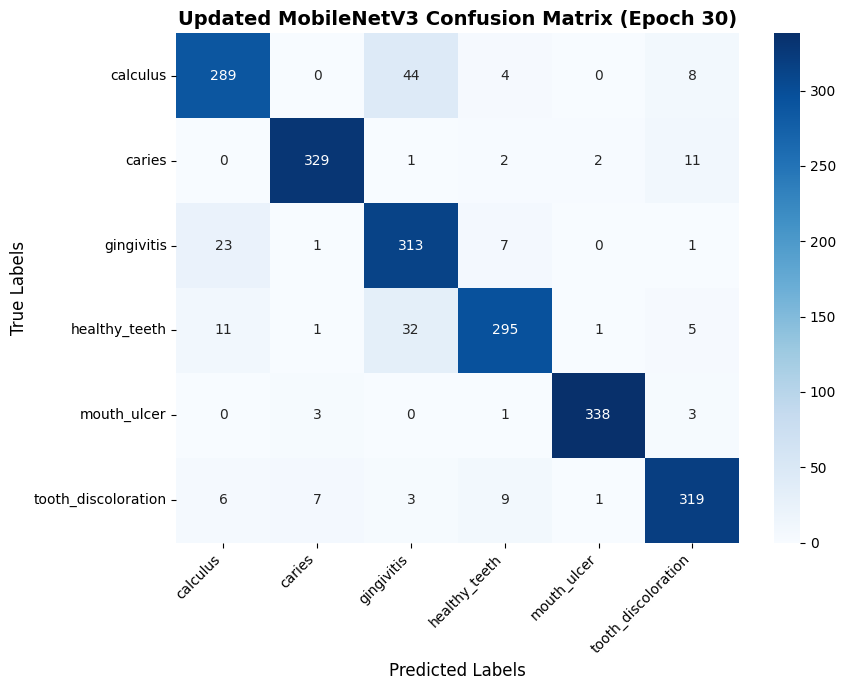

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("Generating updated predictions on Test Dataset...")
y_true = np.concatenate([y for x, y in fast_test_ds], axis=0)
predictions = best_model.predict(fast_test_ds)
y_pred = np.argmax(predictions, axis=1)

print("\n" + "="*60)
print("        UPDATED MOBILENETV3 CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))
print("="*60)

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Updated MobileNetV3 Confusion Matrix (Epoch 30)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/mobilenetv3_updated_confusion_matrix.png', dpi=300)
plt.show()

In [ ]:
import json

# 1. extended_history-யில் உள்ள விவரங்களை Dictionary-ஆக எடுத்தல்
history_dict = extended_history.history

# 2. Google Drive-இல் சேமிக்கப்பட வேண்டிய கோப்பின் பாதை (Path)
history_filepath = '/content/drive/MyDrive/mobilenetv3_training_history.json'

# 3. JSON கோப்பாக Google Drive-இல் சேமித்தல்
with open(history_filepath, 'w') as json_file:
    json.dump(history_dict, json_file)

print(f"Training history successfully saved to Google Drive: {history_filepath}")

Training history successfully saved to Google Drive: /content/drive/MyDrive/mobilenetv3_training_history.json


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading MobileNetV3 model...
Model loaded successfully!

Upload the teeth image for testing:


Saving WhatsApp Image 2026-07-20 at 14.45.06.jpeg to WhatsApp Image 2026-07-20 at 14.45.06 (1).jpeg


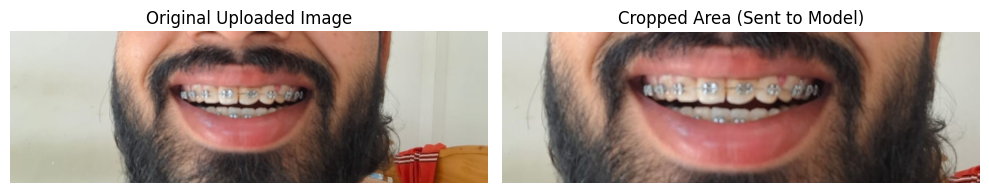


                PREDICTION RESULT
 Predicted Class : HEALTHY_TEETH
 Confidence      : 82.52%

All Class Probabilities:
 - calculus             :   0.48%
 - caries               :   0.01%
 - gingivitis           :   0.47%
 - healthy_teeth        :  82.52%
 - mouth_ulcer          :   0.58%
 - tooth_discoloration  :  15.95%


In [7]:
import cv2
import numpy as np
import tensorflow as tf
from google.colab import drive, files
import matplotlib.pyplot as plt

# =====================================================
# 1. Google Drive Mount & Model Load
# =====================================================
drive.mount('/content/drive')

print("\nLoading MobileNetV3 model...")
model = tf.keras.models.load_model('/content/drive/MyDrive/mobilenetv3_checkpoint.keras')
print("Model loaded successfully!\n")

class_names = ['calculus', 'caries', 'gingivitis', 'healthy_teeth', 'mouth_ulcer', 'tooth_discoloration']

# =====================================================
# 2. Upload Image
# =====================================================
print("Upload the teeth image for testing:")
uploaded = files.upload()

for filename in uploaded.keys():
    # Read image using OpenCV
    img_bgr = cv2.imread(filename)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    h, w, _ = img_rgb.shape

    # =====================================================
    # 3. Center Crop Logic (Removes 15% edges - Lips & Skin)
    # புகைப்படத்தின் வெளிப்பக்க உதடு/சதைப்பகுதிகளை நீக்க
    # நடுப்பகுதியை மட்டும் Auto-Crop செய்யும் முறை
    # =====================================================
    crop_top = int(h * 0.15)
    crop_bottom = int(h * 0.85)
    crop_left = int(w * 0.15)
    crop_right = int(w * 0.85)

    cropped_rgb = img_rgb[crop_top:crop_bottom, crop_left:crop_right]

    # Resize cropped image to 224x224 for MobileNetV3
    resized_img = cv2.resize(cropped_rgb, (224, 224))
    img_array = np.expand_dims(resized_img, axis=0) # Shape: (1, 224, 224, 3)

    # =====================================================
    # 4. Model Prediction
    # =====================================================
    predictions = model.predict(img_array, verbose=0)
    probabilities = predictions[0]

    predicted_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_index]
    confidence = probabilities[predicted_index] * 100

    # =====================================================
    # 5. Display Original vs Cropped Image & Results
    # =====================================================
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original Uploaded Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cropped_rgb)
    plt.title("Cropped Area (Sent to Model)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 55)
    print("                PREDICTION RESULT")
    print("=" * 55)
    print(f" Predicted Class : {predicted_class.upper()}")
    print(f" Confidence      : {confidence:.2f}%")
    print("=" * 55)

    print("\nAll Class Probabilities:")
    for name, prob in zip(class_names, probabilities):
        print(f" - {name:<20} : {prob * 100:6.2f}%")
    print("=" * 55)